In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np  # Thêm thư viện numpy để tính log

In [ ]:
df = pd.read_json('../../data/raw_concat/tobacco.json')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['M_Est_tob_curr_std', 'M_Est_smk_curr_std', 'M_Est_tob_curr', 'M_Est_smk_curr', 'M_Est_tob_curr_users', 'M_Est_smk_curr_users']


,ParentLocationCode,SpatialDim,Dim1,Value,NumericValue,Date,IndicatorCode
0,NaN,WPR,SEX_MLE,47.8 [44.6-51.2],47.8,2026-01-15T18:43:44.287+01:00,M_Est_tob_curr_std
1,NaN,EUR,SEX_FMLE,22.3 [20.6-24.2],22.3,2026-01-15T18:43:44.287+01:00,M_Est_tob_curr_std
2,SEAR,BTN,SEX_MLE,28.3 [20.7-35.8],28.3,2026-01-15T18:43:44.287+01:00,M_Est_tob_curr_std
3,AFR,CPV,SEX_MLE,17.5 [13.2-21.8],17.5,2026-01-15T18:43:44.287+01:00,M_Est_tob_curr_std
4,AFR,NER,SEX_FMLE,0.9 [0.3-1.5],0.9,2026-01-15T18:43:44.287+01:00,M_Est_tob_curr_std
...,...,...,...,...,...,...,...
33721,AMR,CHL,SEX_BTSX,5 335 000,5335000.0,2026-01-15T19:27:58.963+01:00,M_Est_smk_curr_users
33722,EUR,KGZ,SEX_MLE,756 000,756000.0,2026-01-15T19:27:58.963+01:00,M_Est_smk_curr_users
33723,EMR,OMN,SEX_MLE,108 000,108000.0,2026-01-15T19:27:58.963+01:00,M_Est_smk_curr_users
33724,WPR,AUS,SEX_MLE,2 013 000,2013000.0,2026-01-15T19:27:58.963+01:00,M_Est_smk_curr_users


In [ ]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

In [ ]:
df_pivot = df[df['IndicatorCode'].isin(indicators)] \
    .pivot_table(
        index=['SpatialDim', 'Dim1'],
        columns='IndicatorCode',
        values='NumericValue'
    )

corr_matrix = df_pivot.corr()


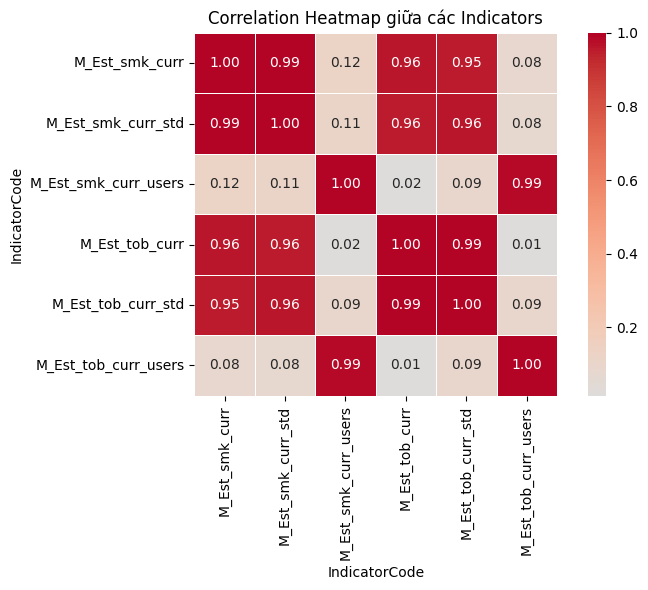

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # hiện hệ số corr
    fmt=".2f",
    cmap="coolwarm",
    center=0,            # lấy 0 làm trung tâm
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap giữa các Indicators")
plt.tight_layout()
plt.show()


In [ ]:
countries = df["SpatialDim"].unique()
times = pd.to_datetime(df["TimeDim"], format="ISO8601", utc=True)
length, len_countries = len(df), len(countries)
min_date, max_date = times.min().year, times.max().year

print(f"Bộ tobacco có {length} mẫu, thu thập từ {len_countries} quốc gia, trong khoảng thời gian từ {min_date} đến {max_date}!")

Bộ tobacco có 33726 mẫu, thu thập từ 174 quốc gia, trong khoảng thời gian từ 2026 đến 2026!


In [ ]:
min_year = df['Date'].min()
max_year = df['Date'].max()
print(f'{min_year} - {max_year}')
df['Date'].nunique()


2026-01-15T17:18:01.58+01:00 - 2026-01-15T19:27:58.963+01:00


5

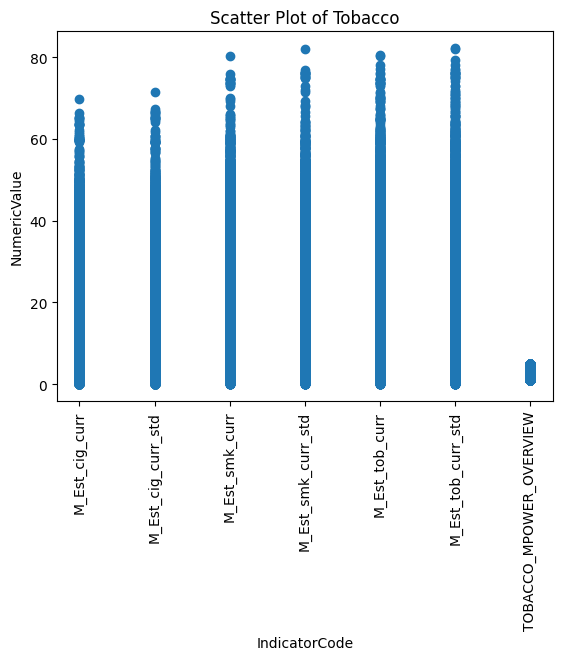

In [ ]:
plt.figure()
plt.scatter(df['IndicatorCode'], df['NumericValue'])
plt.xlabel('IndicatorCode')
plt.ylabel('NumericValue')
plt.title('Scatter Plot of Tobacco')
plt.xticks(rotation=90)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_15616\3881616122.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


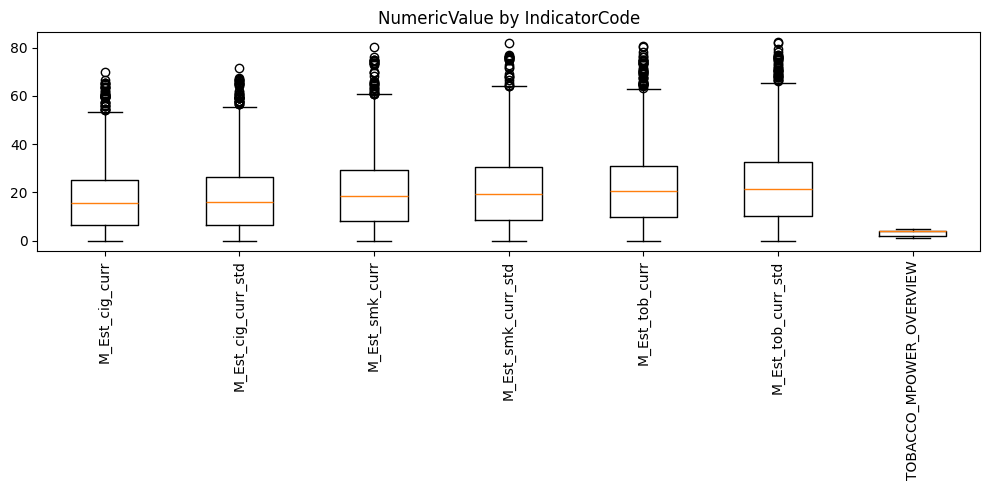

In [ ]:
plt.figure(figsize=(10,5))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
plt.xticks(rotation=90)
plt.title('NumericValue by IndicatorCode')
plt.tight_layout()
plt.show()


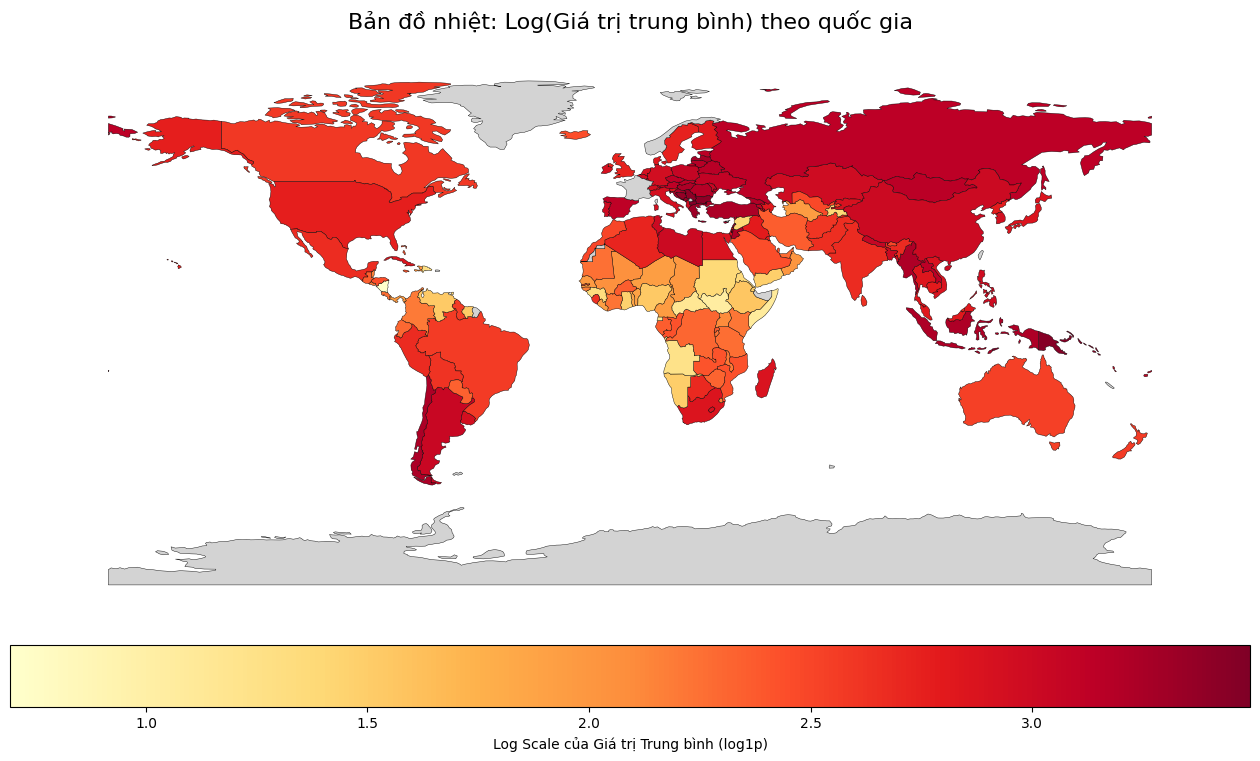

In [ ]:
# ==============================
# 1. KIỂM TRA & CHUẨN HÓA (Đã sửa lỗi Mixed Timezones)
# ==============================
df["NumericValue"] = pd.to_numeric(df["NumericValue"], errors="coerce")

# Thêm utc=True để xử lý các múi giờ khác nhau
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
df_grouped = (
    df.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
# Việc cộng 1 giúp tránh lỗi nếu MeanValue bằng 0
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
world = gpd.read_file("D:/FPTU/SP26/ADY201m/semantic analysis/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",
    right_on="SpatialDim"
)

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Sử dụng cột "LogMeanValue" để vẽ màu
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị Trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Bản đồ nhiệt: Log(Giá trị trung bình) theo quốc gia", 
    fontsize=16, 
    pad=20
)

ax.axis("off")
plt.show()